# 01 — Data Ingestion & Exploration

**Pipeline step:** Pull data from both sources, explore, validate, and save.

```
Db2 ──→ Driver Records (100K households)
     ──→ Household Coordinates (lat/long)

Socrata API ──→ Chicago Crash Data (6 months)
```

**Output:** Cleaned CSVs in `data/processed/` ready for clustering and training.

In [3]:
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
%matplotlib inline

---
## 1. Db2 — Driver Records
One record per household using the latest insurance policy.
Joins across: HOUSEHOLD, DRIVER, POLICY, CLAIM tables.

In [4]:
driver_df = pd.read_csv('/Users/omerpoyraz/Desktop/AI Eng/MLOps/insurance_mlops/data/processed/drivers_raw.csv')


In [5]:
driver_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100346 entries, 0 to 100345
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   HOUSEHOLD_ID        100346 non-null  object 
 1   POLICY_ID           100346 non-null  object 
 2   ZIPCODE             100346 non-null  int64  
 3   NB_DRIVERS          100346 non-null  float64
 4   UNDER25             100346 non-null  int64  
 5   OVER60              100346 non-null  int64  
 6   MALE25              100346 non-null  int64  
 7   PRIM_DRIVER_AGE     100346 non-null  int64  
 8   PRIM_DRIVER_GENDER  100346 non-null  object 
 9   MAKE_MODEL          100346 non-null  object 
 10  MODEL_YEAR          100346 non-null  int64  
 11  INITIAL_ODOMETER    100346 non-null  float64
 12  LOW_MILEAGE_USE     100346 non-null  int64  
 13  NB_CLAIMS           100346 non-null  float64
 14  CLAIM_TOTAL         979 non-null     float64
 15  NB_PRIM_CLAIMS      100346 non-nul

In [6]:
driver_df.describe()

,ZIPCODE,NB_DRIVERS,UNDER25,OVER60,MALE25,PRIM_DRIVER_AGE,MODEL_YEAR,INITIAL_ODOMETER,LOW_MILEAGE_USE,NB_CLAIMS,CLAIM_TOTAL,NB_PRIM_CLAIMS,PRIM_CLAIM_TOTAL,RISK
count,100346.000000,100346.000000,100346.000000,100346.000000,100346.000000,100346.000000,100346.000000,100346.000000,100346.000000,100346.000000,979.000000,100346.000000,857.000000,100346.000000
mean,60394.257818,2.672354,0.016214,1.249517,0.008072,57.424232,2008.816834,174702.835609,0.101967,0.009756,12486.692543,3.274869,12268.322637,28.117374
std,240.241415,1.414882,0.126928,1.047207,0.089593,19.147970,5.134612,107340.627497,0.302607,0.098291,13698.689573,2.409208,13648.793757,6.938707
min,60002.000000,1.000000,0.000000,0.000000,0.000000,24.000000,1990.000000,9024.000000,0.000000,0.000000,1000.000000,1.000000,1000.000000,3.000000
25%,60131.000000,1.000000,0.000000,0.000000,0.000000,41.000000,2006.000000,90192.000000,0.000000,0.000000,1895.000000,2.000000,1900.000000,23.000000
50%,60456.000000,2.000000,0.000000,1.000000,0.000000,57.000000,2010.000000,153984.000000,0.000000,0.000000,2780.000000,3.000000,2750.000000,29.000000
75%,60618.000000,4.000000,0.000000,2.000000,0.000000,74.000000,2013.000000,236805.000000,0.000000,0.000000,24472.000000,4.000000,23851.000000,33.000000
max,60940.000000,5.000000,2.000000,5.000000,2.000000,91.000000,2017.000000,669312.000000,1.000000,1.000000,48035.500000,27.000000,47748.000000,59.000000


### 1.1 Check for nulls and data quality

In [7]:
# Null counts per column
null_counts = driver_df.isnull().sum()
null_pct = (null_counts / len(driver_df) * 100).round(1)

null_report = pd.DataFrame({'nulls': null_counts, 'pct': null_pct})
null_report[null_report['nulls'] > 0]

,nulls,pct
CLAIM_TOTAL,99367,99.0
PRIM_CLAIM_TOTAL,99489,99.1


### 1.2 Explore the target: RISK

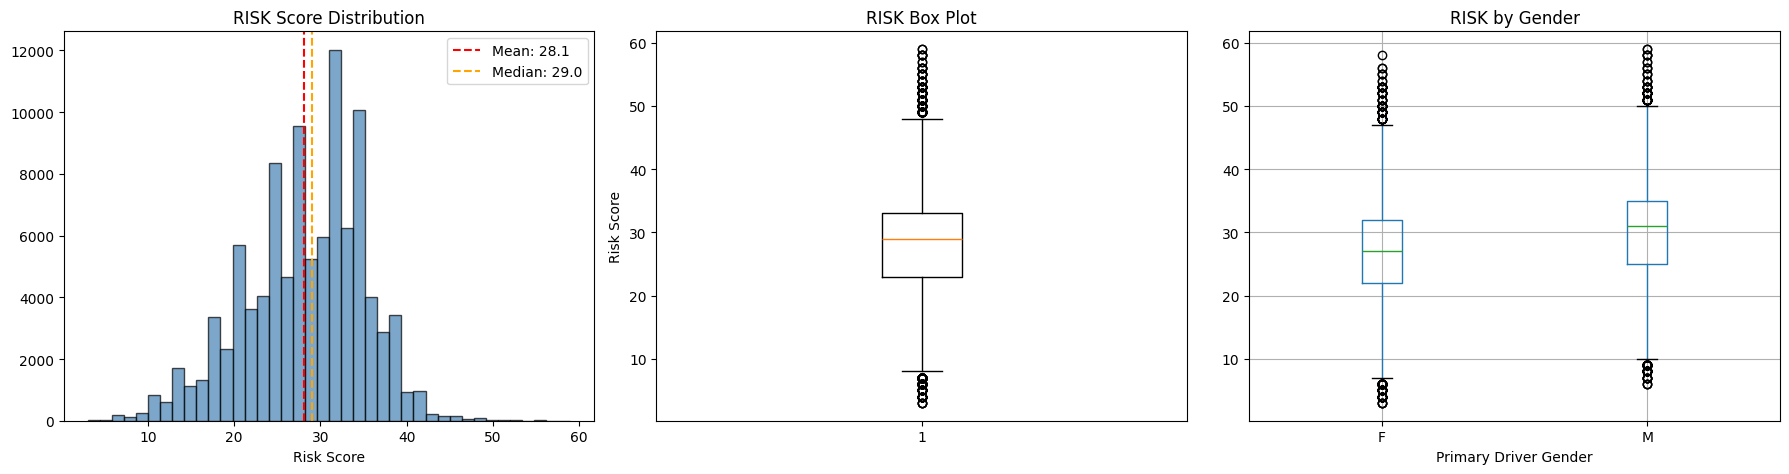

RISK range: 3 - 59
Mean: 28.1, Std: 6.9


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution
axes[0].hist(driver_df['RISK'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(driver_df['RISK'].mean(), color='red', linestyle='--',
                label=f"Mean: {driver_df['RISK'].mean():.1f}")
axes[0].axvline(driver_df['RISK'].median(), color='orange', linestyle='--',
                label=f"Median: {driver_df['RISK'].median():.1f}")
axes[0].set_title('RISK Score Distribution')
axes[0].set_xlabel('Risk Score')
axes[0].legend()

# Box plot
axes[1].boxplot(driver_df['RISK'].dropna(), vert=True)
axes[1].set_title('RISK Box Plot')
axes[1].set_ylabel('Risk Score')

# Risk by gender
driver_df.boxplot(column='RISK', by='PRIM_DRIVER_GENDER', ax=axes[2])
axes[2].set_title('RISK by Gender')
axes[2].set_xlabel('Primary Driver Gender')
fig.suptitle('')

plt.tight_layout()
plt.show()

print(f"RISK range: {driver_df['RISK'].min()} - {driver_df['RISK'].max()}")
print(f"Mean: {driver_df['RISK'].mean():.1f}, Std: {driver_df['RISK'].std():.1f}")

### 1.3 Explore key features

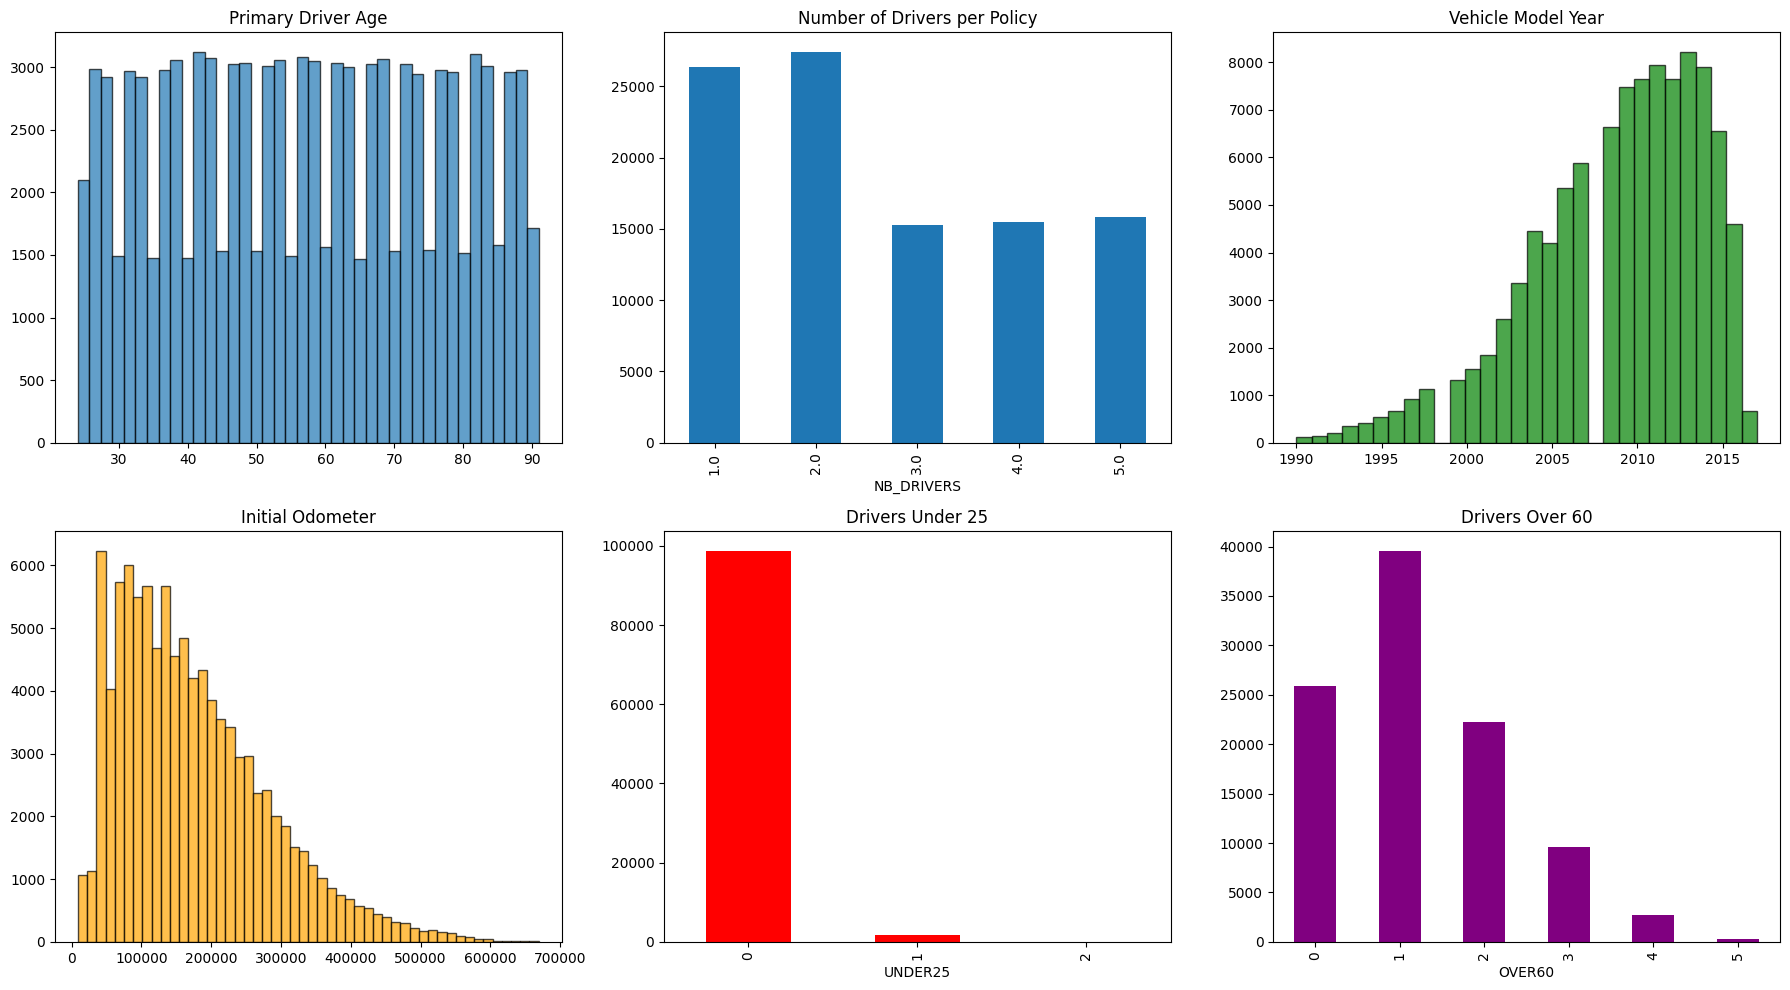

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Primary driver age
axes[0, 0].hist(driver_df['PRIM_DRIVER_AGE'], bins=40, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Primary Driver Age')

# Number of drivers
driver_df['NB_DRIVERS'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Number of Drivers per Policy')

# Model year
axes[0, 2].hist(driver_df['MODEL_YEAR'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_title('Vehicle Model Year')

# Odometer
axes[1, 0].hist(driver_df['INITIAL_ODOMETER'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('Initial Odometer')

# Under 25 drivers
driver_df['UNDER25'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='red')
axes[1, 1].set_title('Drivers Under 25')

# Over 60 drivers
driver_df['OVER60'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 2], color='purple')
axes[1, 2].set_title('Drivers Over 60')

plt.tight_layout()
plt.show()

### 1.4 Correlation with RISK

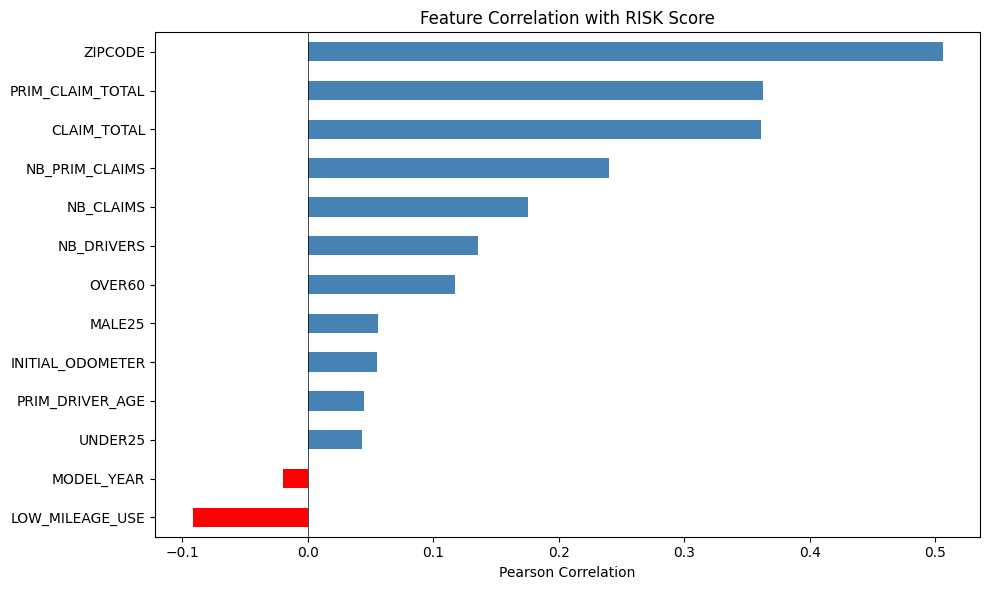

In [10]:
numeric_cols = driver_df.select_dtypes(include=[np.number]).columns
corr_with_risk = driver_df[numeric_cols].corr()['RISK'].drop('RISK').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if v < 0 else 'steelblue' for v in corr_with_risk]
corr_with_risk.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Correlation with RISK Score')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

---
## 2. Db2 — Household Coordinates
Needed for computing hotspot distances in notebook 02.

In [11]:
hh_df = pd.read_csv('/Users/omerpoyraz/Desktop/AI Eng/MLOps/insurance_mlops/data/processed/household_coords.csv')
print(f"Shape: {hh_df.shape}")
hh_df.head()

Shape: (100169, 3)


,HOUSEHOLD_ID,LATITUDE,LONGITUDE
0,EF07926,42.106590,-87.776629
1,MJ58257,41.950807,-87.658336
2,DJ17771,41.901205,-87.672055
3,ML06244,42.137056,-87.851188
4,CK03697,41.770331,-87.731943


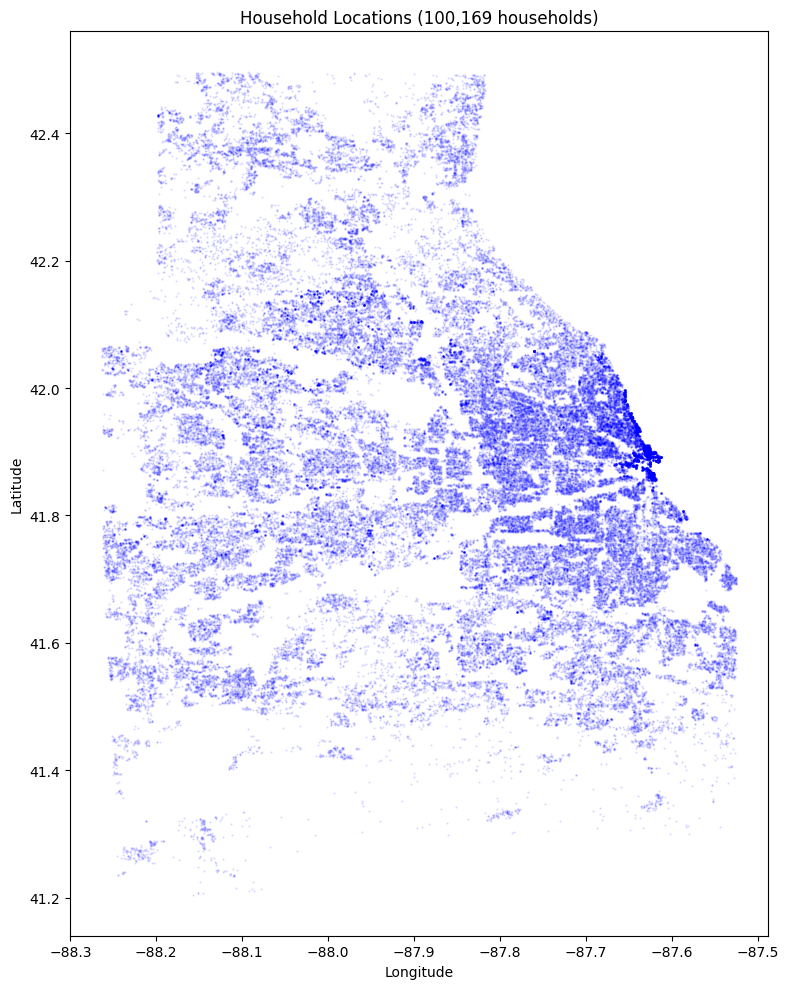

In [12]:
# Quick scatter plot of household locations
fig, ax = plt.subplots(figsize=(8, 10))
ax.scatter(hh_df['LONGITUDE'], hh_df['LATITUDE'], s=0.5, alpha=0.1, color='blue')
ax.set_title(f'Household Locations ({len(hh_df):,} households)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

---
## 3. Socrata — Chicago Crash Data
6 months of traffic crash records. Used for hotspot clustering.

In [13]:
from sodapy import Socrata
import pandas as pd
from datetime import datetime, timedelta

# Fetch crash data
client = Socrata("data.cityofchicago.org", None)
cutoff = (datetime.now() - timedelta(days=6 * 30)).strftime("%Y-%m-%dT%H:%M:%S")

results = client.get(
    "85ca-t3if",
    where=f"crash_date > '{cutoff}'",
    limit=100000,
)
client.close()

raw_crashes = pd.DataFrame.from_records(results)
print(f"Raw records: {len(raw_crashes):,}")
raw_crashes.head()

Raw records: 52,653


,crash_record_id,crash_date,posted_speed_limit,traffic_control_device,device_condition,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,report_type,crash_type,hit_and_run_i,damage,date_police_notified,prim_contributory_cause,sec_contributory_cause,street_no,street_direction,street_name,beat_of_occurrence,num_units,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,injuries_unknown,crash_hour,crash_day_of_week,crash_month,latitude,longitude,location,intersection_related_i,crash_date_est_i,statements_taken_i,private_property_i,photos_taken_i,dooring_i,work_zone_i,work_zone_type,workers_present_i,lane_cnt
0,7290010949d2583da362c353acf06bb3ef24fac55c6a8e...,2026-02-14T00:50:00.000,30,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",REAR END,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,UNKNOWN,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,Y,"OVER $1,500",2026-02-14T01:40:00.000,FOLLOWING TOO CLOSELY,UNABLE TO DETERMINE,1000,W,18TH ST,1235,2,NO INDICATION OF INJURY,0,0,0,0,0,2,0,0,7,2,41.8581311268,-87.6516026311,"{'type': 'Point', 'coordinates': [-87.65160263...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3d5f0d3aadbf0c5a2805973fe529ee8695d0633d88c944...,2026-02-14T00:20:00.000,25,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,ONE-WAY,STRAIGHT AND LEVEL,DRY,UNKNOWN,NOT ON SCENE (DESK REPORT),INJURY AND / OR TOW DUE TO CRASH,Y,"OVER $1,500",2026-02-14T01:30:00.000,UNABLE TO DETERMINE,NOT APPLICABLE,125,N,LAMON AVE,1532,2,NO INDICATION OF INJURY,0,0,0,0,0,1,0,0,7,2,41.8826427211,-87.7476588723,"{'type': 'Point', 'coordinates': [-87.74765887...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,78ab0671fdbec4d726ad21a98673c03fcb803dbd85b20d...,2026-02-14T00:08:00.000,30,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE SAME DIRECTION,DIVIDED - W/MEDIAN BARRIER,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,ON SCENE,NO INJURY / DRIVE AWAY,NaN,"OVER $1,500",2026-02-14T00:15:00.000,IMPROPER OVERTAKING/PASSING,FAILING TO YIELD RIGHT-OF-WAY,150,N,WACKER DR,122,2,NO INDICATION OF INJURY,0,0,0,0,0,2,0,0,7,2,41.884525461,-87.6372163925,"{'type': 'Point', 'coordinates': [-87.63721639...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,09d3c48cc84a8c211275a11c99fe5944ac41aa0a7bdbe5...,2026-02-14T00:02:00.000,30,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE SAME DIRECTION,NOT DIVIDED,STRAIGHT ON HILLCREST,DRY,NO DEFECTS,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,Y,"OVER $1,500",2026-02-14T00:05:00.000,IMPROPER OVERTAKING/PASSING,UNABLE TO DETERMINE,2001,E,103RD ST,434,2,NO INDICATION OF INJURY,0,0,0,0,0,6,0,0,7,2,41.7078228876,-87.5758832257,"{'type': 'Point', 'coordinates': [-87.57588322...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0a92baca4f377fe3449d184159af07fecad8d25319e1df...,2026-02-13T23:40:00.000,25,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,NO INJURY / DRIVE AWAY,Y,"OVER $1,500",2026-02-13T23:41:00.000,UNABLE TO DETERMINE,UNABLE TO DETERMINE,1617,W,91ST ST,2221,3,NO INDICATION OF INJURY,0,0,0,0,0,1,0,23,6,2,41.7283400997,-87.6635791864,"{'type': 'Point', 'coordinates': [-87.66357918...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Clean crash data — keep only needed columns, convert types, drop nulls
columns = ['injuries_fatal', 'injuries_total', 'latitude', 'longitude']
crashes_df = raw_crashes[columns].copy()

crashes_df = crashes_df.astype({
    'injuries_fatal': float,
    'injuries_total': float,
    'latitude': float,
    'longitude': float,
})

crashes_df = crashes_df.dropna()
crashes_df = crashes_df[
    (crashes_df["longitude"] != 0) & (crashes_df["latitude"] != 0)
]
crashes_df = crashes_df.reset_index(drop=True)

print(f"Cleaned crash data: {len(crashes_df):,} records")
crashes_df.describe()

Cleaned crash data: 52,035 records


,injuries_fatal,injuries_total,latitude,longitude
count,52035.000000,52035.000000,52035.000000,52035.000000
mean,0.000922,0.226079,41.860703,-87.680745
std,0.034506,0.609725,0.086633,0.059260
min,0.000000,0.000000,41.644670,-87.939678
25%,0.000000,0.000000,41.787666,-87.722266
50%,0.000000,0.000000,41.876722,-87.676550
75%,0.000000,0.000000,41.928356,-87.636646
max,2.000000,12.000000,42.022669,-87.524587


In [16]:
# Crash categories
killed = crashes_df[crashes_df['injuries_fatal'] > 0]
injured = crashes_df[(crashes_df['injuries_total'] > 0) & (crashes_df['injuries_fatal'] == 0)]
no_injury = crashes_df[(crashes_df['injuries_fatal'] == 0) & (crashes_df['injuries_total'] == 0)]

print(f"Total crashes:     {len(crashes_df):,}")
print(f"Fatal:             {len(killed):,}")
print(f"Injury (non-fatal):{len(injured):,}")
print(f"No injury:         {len(no_injury):,}")

Total crashes:     52,035
Fatal:             41
Injury (non-fatal):8,420
No injury:         43,574


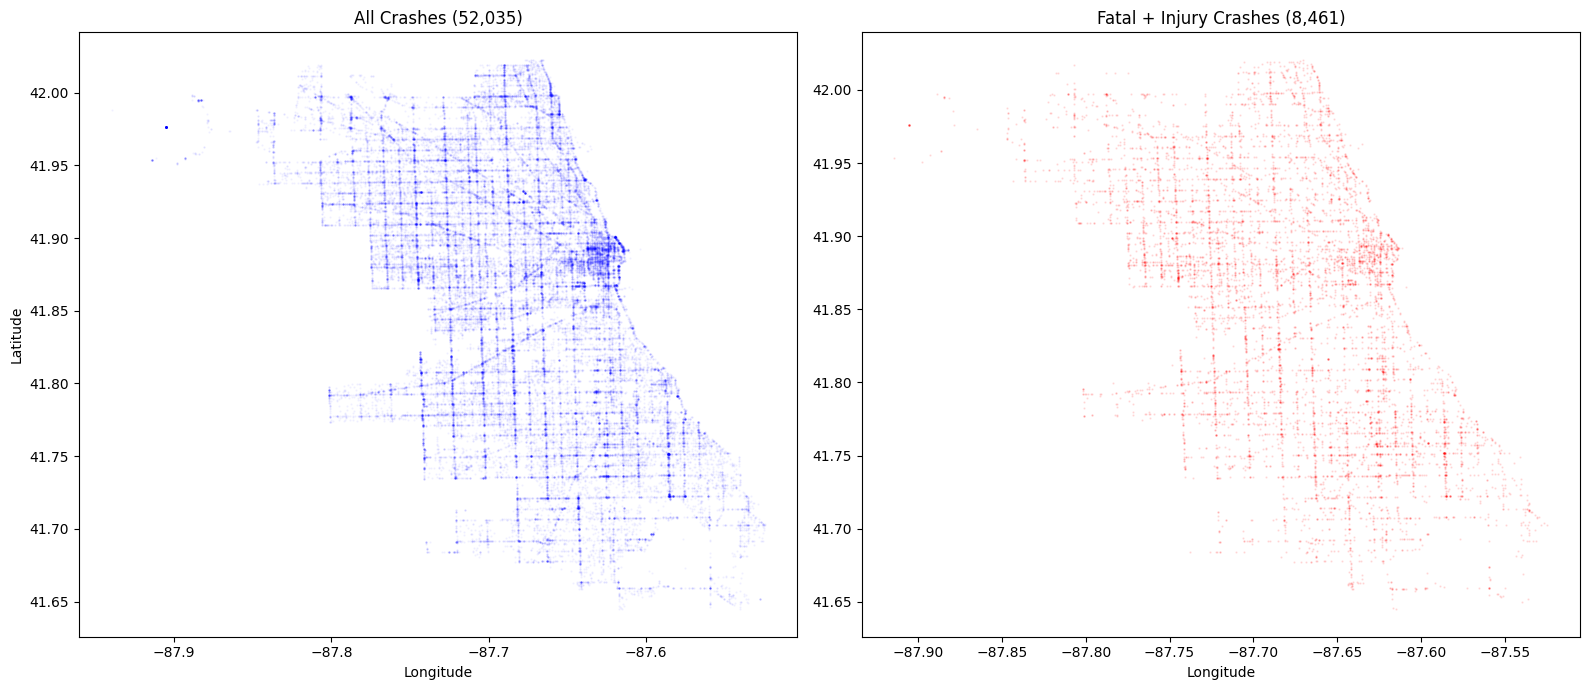

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# All crashes
axes[0].scatter(crashes_df['longitude'], crashes_df['latitude'],
                s=0.3, alpha=0.05, color='blue')
axes[0].set_title(f'All Crashes ({len(crashes_df):,})')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Fatal + injury only
injury_all = pd.concat([killed, injured])
axes[1].scatter(injury_all['longitude'], injury_all['latitude'],
                s=0.5, alpha=0.1, color='red')
axes[1].set_title(f'Fatal + Injury Crashes ({len(injury_all):,})')
axes[1].set_xlabel('Longitude')

plt.tight_layout()
plt.show()

---
## 4. Validate & Save
Save cleaned data for use in notebook 02 (clustering + training).

In [18]:
# Validate crash data
required = ["latitude", "longitude", "injuries_total", "injuries_fatal"]
for col in required:
    crashes_df[col] = pd.to_numeric(crashes_df[col], errors="coerce")
crashes_df = crashes_df.dropna(subset=["latitude", "longitude"])
print(f"Crashes after validation: {len(crashes_df):,}")

# Validate driver data
assert "HOUSEHOLD_ID" in driver_df.columns, "Missing HOUSEHOLD_ID"
assert "RISK" in driver_df.columns, "Missing RISK"
print(f"Drivers: {len(driver_df):,}")

Crashes after validation: 52,035
Drivers: 100,346


In [21]:

crashes_df.to_csv('/Users/omerpoyraz/Desktop/AI Eng/MLOps/insurance_mlops/data/processed/crashes_cleaned.csv', index=False)

print('Saved:')
print(f'  crashes_cleaned.csv   — {len(crashes_df):,} rows')


Saved:
  crashes_cleaned.csv   — 52,035 rows


---
### Summary
| Source | Dataset | Records | Status |
|--------|---------|--------:|--------|
| Db2 | Driver records | ~100K | ✅ Saved |
| Db2 | Household coords | ~100K | ✅ Saved |
| Socrata | Chicago crashes | ~50K | ✅ Saved |

**Next:** Notebook 02 — Clustering & Training